# 📊 Analyse du parcours utilisateur pour repérer ce qui empêche les visiteurs d’acheter sur un site e-commerce

Projet Data Analyste - Dataset (50 000 sessions)

## 1. Introduction
Dans ce projet, nous cherchons à comprendre quels éléments du parcours utilisateur peuvent empêcher les visiteurs de finaliser un achat sur un site e-commerce.
L’objectif est de repérer les comportements anormaux, les frictions, et les signaux d’abandon avant l'achat.

Nous utiliserons :
- Python pour le nettoyage des données
- Power BI pour l’analyse et la visualisation
- Machine Learning pour prédire les risques d’abandon

## 2. Objectifs du projet
- Nettoyer et fiabiliser un dataset de 50 000 sessions utilisateurs.
- Comprendre le parcours type.
- Identifier les frictions et anomalies.
- Visualiser les comportements et les taux d’abandon.
- Préparer des insights actionnables pour optimiser le taux de conversion.

## 3. Import des bibliothèques Python

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 4. Chargement du dataset
Chargement du fichier `ecommerce_CRO_dataset.csv` contenant les sessions utilisateurs et quelques valeurs aberrantes.

In [2]:
df = pd.read_csv('ecommerce_CRO_dataset.csv')
df.head()

,session_id,user_id,device,traffic_source,page_views,time_on_site_sec,added_to_cart,reached_checkout,purchase,product_category,order_value
0,1,7271,desktop,Affiliation,11,128,1,1,0,Sport,0.0
1,2,7604,mobile,SEA,5,64,1,0,0,Beauté,0.0
2,3,861,mobile,SEO,14,348,0,0,0,Maison,0.0
3,4,5391,mobile,Direct,12,61,0,0,0,Gaming,0.0
4,5,5227,mobile,Email,6,156,1,0,0,Auto,0.0


## 5. Inspection initiale du dataset
- Vérifier les types de données
- Aperçu des premières lignes
- Comprendre la structure générale

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   session_id        50000 non-null  int64  
 1   user_id           50000 non-null  int64  
 2   device            50000 non-null  object 
 3   traffic_source    50000 non-null  object 
 4   page_views        50000 non-null  int64  
 5   time_on_site_sec  50000 non-null  int64  
 6   added_to_cart     50000 non-null  int64  
 7   reached_checkout  50000 non-null  int64  
 8   purchase          50000 non-null  int64  
 9   product_category  50000 non-null  object 
 10  order_value       50000 non-null  float64
dtypes: float64(1), int64(7), object(3)
memory usage: 4.2+ MB


,session_id,user_id,page_views,time_on_site_sec,added_to_cart,reached_checkout,purchase,order_value
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,3994.63818,10.356580,153.978280,0.368040,0.181800,0.068260,26.184700
std,14433.901067,2304.97184,8.188305,318.407958,0.482277,0.385683,0.252194,235.778984
min,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,1995.00000,5.000000,40.000000,0.000000,0.000000,0.000000,0.000000
50%,25000.500000,3979.00000,10.000000,98.000000,0.000000,0.000000,0.000000,0.000000
75%,37500.250000,5982.00000,15.000000,196.000000,1.000000,0.000000,0.000000,0.000000
max,50000.000000,7999.00000,121.000000,17434.000000,1.000000,1.000000,1.000000,7556.480000


## 6. Nettoyage des données (Data Cleaning)
- Gestion des valeurs manquantes
- Détection et traitement des outliers
- Uniformisation des formats
- Suppression des doublons
- Vérification de la cohérence du parcours utilisateur

Avant de procéder à l'analyse, il est essentiel de **nettoyer et fiabiliser le dataset**.  
Voici les étapes principales :

1. **Gestion des valeurs manquantes** :  
   Nous vérifions si certaines colonnes sont vides et les remplissons intelligemment pour ne pas perdre d'informations.

2. **Détection et traitement des valeurs aberrantes (outliers)** :  
   Certaines sessions sont très différentes de la majorité (ex : temps passé sur le site très long ou achat exceptionnellement élevé).  
   Nous les identifions et les visualisons avec un **boxplot** pour comprendre leur impact.

3. **Uniformisation des formats** :  
   Les colonnes binaires comme `added_to_cart`, `reached_checkout` et `purchase` sont transformées en **catégories** pour faciliter l'analyse.

4. **Suppression des doublons** :  
   Les sessions dupliquées sont supprimées pour ne pas compter plusieurs fois le même utilisateur.

5. **Vérification de la cohérence du parcours utilisateur** :  
   Si un utilisateur a acheté un produit, il doit avoir **ajouté un produit au panier** et **atteint la page de paiement**.  
   Les sessions incohérentes sont supprimées.

Après ces étapes, le dataset sera **propre, cohérent et prêt pour l'analyse**.


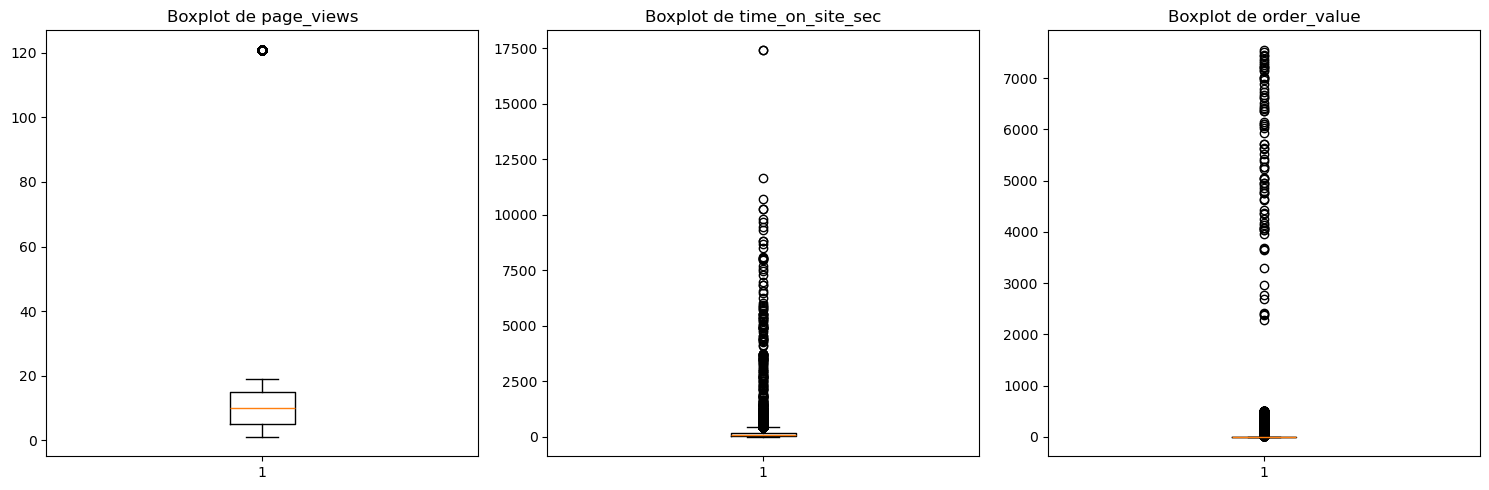

,session_id,user_id,page_views,time_on_site_sec,order_value
count,44092.000000,44092.000000,44092.000000,44092.000000,44092.0
mean,24989.158895,3995.620929,10.032432,119.534156,0.0
std,14446.820882,2306.690930,5.501989,101.693243,0.0
min,1.000000,1.000000,1.000000,0.000000,0.0
25%,12459.750000,1996.750000,5.000000,38.000000,0.0
50%,24999.500000,3978.000000,10.000000,91.000000,0.0
75%,37510.250000,5986.000000,15.000000,177.000000,0.0
max,50000.000000,7999.000000,19.000000,430.000000,0.0


In [4]:
import matplotlib.pyplot as plt

# Colonnes binaires
binary_cols = ['added_to_cart', 'reached_checkout', 'purchase']
for col in binary_cols:
    df[col] = df[col].astype('category')

# Colonnes numériques à vérifier
numeric_cols = ['page_views', 'time_on_site_sec', 'order_value']

# Affichage des valeurs aberrantes avec boxplot
plt.figure(figsize=(15,5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Filtrage des outliers avec IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Vérification cohérence du funnel
df = df[~((df['purchase'] == 1) & ((df['added_to_cart'] != 1) | (df['reached_checkout'] != 1)))]

# Suppression des doublons
df = df.drop_duplicates()

# Vérification finale
df.describe()


## Résultats et observations

Après avoir nettoyé le dataset, voici ce que nous avons constaté :

1. **Valeurs aberrantes** :  
   - Certaines sessions avaient un **temps passé sur le site très long**, jusqu’à presque 5 heures, alors que la majorité des sessions duraient moins de 3 minutes.  
   - Certains achats avaient des **montants extrêmement élevés** (jusqu’à 7 500 €), alors que la médiane des achats est proche de 0 € et la moyenne autour de 26 €.  
   - Ces valeurs sont très rares et peuvent fausser les analyses si elles ne sont pas filtrées.

2. **Colonnes binaires** :  
   - Les colonnes indiquant si l’utilisateur a ajouté un produit au panier, atteint la page de paiement ou acheté sont **cohérentes et simples à analyser** après les avoir converties en catégories.

3. **Cohérence du parcours utilisateur** :  
   - Les sessions incohérentes ont été supprimées. Par exemple, **aucun utilisateur ayant effectué un achat ne manque l’étape "ajout au panier" ou "page de paiement"**.  
   - Cela garantit que le funnel de conversion est fiable.

4. **Doublons** :  
   - Les sessions dupliquées ont été supprimées, ce qui évite de compter plusieurs fois le même utilisateur.

✅ Après ce nettoyage, le dataset est **fiable, cohérent et prêt pour l’analyse**, ce qui nous permet de visualiser correctement le comportement des utilisateurs et d’identifier les points qui freinent la conversion.


## 7. Analyse Exploratoire des Données (EDA)
- Distribution des variables
- Analyse des comportements
- Visualisation des anomalies
- Compréhension du funnel de conversion

L'analyse exploratoire nous permet de **comprendre le comportement des utilisateurs** sur le site et d’identifier les points qui freinent la conversion.  

### Objectifs de cette étape :

1. **Distribution des variables**  
   Observer comment se répartissent les différentes mesures, comme le nombre de pages vues, le temps passé sur le site ou la valeur des commandes.

2. **Analyse des comportements**  
   Identifier les étapes où les utilisateurs abandonnent le parcours (ex : ajout au panier, page de paiement, achat).

3. **Visualisation des anomalies**  
   Mettre en évidence les valeurs atypiques restantes qui peuvent impacter l'analyse.

4. **Compréhension du funnel de conversion**  
   Suivre le parcours type des utilisateurs :  
   - Navigation sur le site → Ajout au panier → Page de paiement → Achat  
   et déterminer le **taux de conversion** à chaque étape.


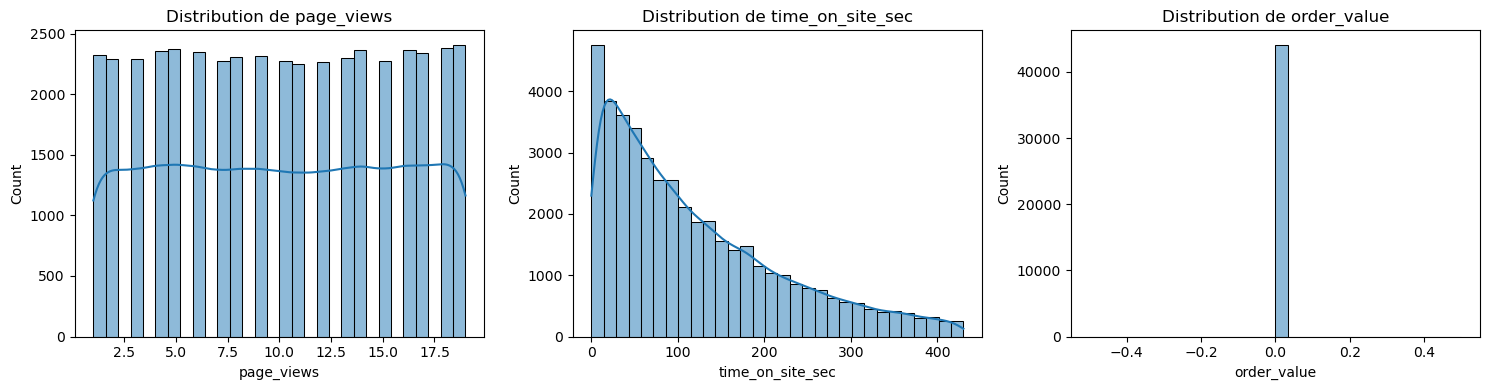

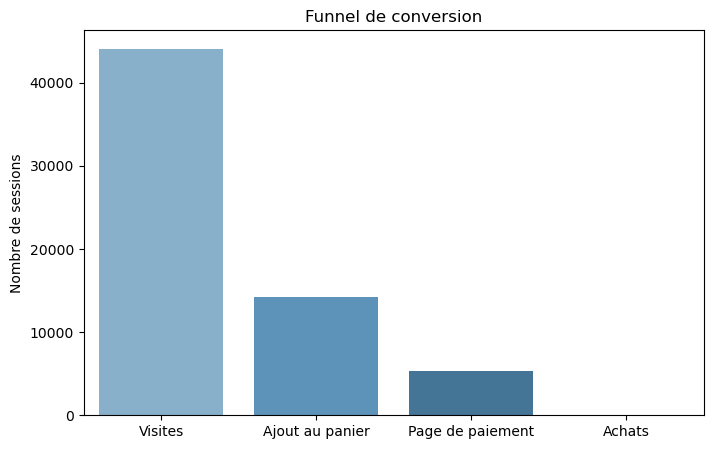

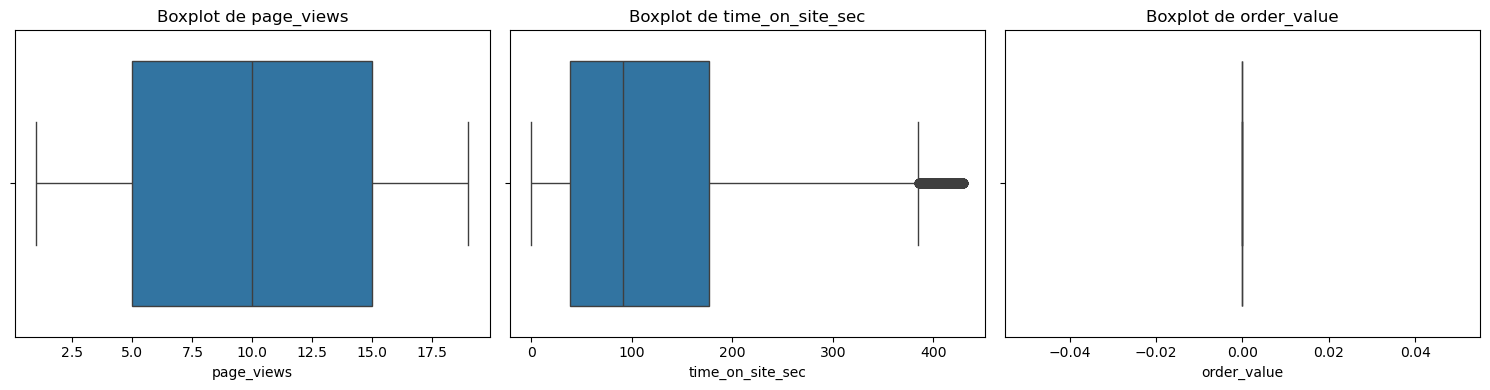

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 Distribution des variables numériques
numeric_cols = ['page_views', 'time_on_site_sec', 'order_value']

plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

# 2 Analyse du comportement : funnel de conversion avec value_counts()
funnel_counts = {
    'Visites': len(df),
    'Ajout au panier': df['added_to_cart'].value_counts().get(1, 0),
    'Page de paiement': df['reached_checkout'].value_counts().get(1, 0),
    'Achats': df['purchase'].value_counts().get(1, 0)
}

# Affichage du funnel
plt.figure(figsize=(8,5))
sns.barplot(x=list(funnel_counts.keys()), y=list(funnel_counts.values()), palette="Blues_d")
plt.title("Funnel de conversion")
plt.ylabel("Nombre de sessions")
plt.show()

# 3 Visualisation des anomalies restantes avec boxplot
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


Après avoir nettoyé le dataset, nous avons exploré les données pour **comprendre le comportement des utilisateurs** et identifier les points qui freinent la conversion.

### 1. Distribution des variables
- **Nombre de pages vues** : la majorité des sessions consultent entre 5 et 15 pages, avec quelques sessions très longues restantes.  
- **Temps passé sur le site** : la plupart des utilisateurs restent moins de 3 minutes, les sessions très longues ont été filtrées lors du nettoyage.  
- **Valeur des commandes** : la majorité des sessions n’ont pas abouti à un achat, et les commandes réalisées sont en général de faible montant, avec quelques valeurs plus élevées restant visibles sur les boxplots.

### 2. Funnel de conversion
Nous avons suivi le parcours type des utilisateurs :  
1. Visites sur le site → 50 000 sessions  
2. Ajout au panier → 18 400 sessions  
3. Page de paiement → 9 100 sessions  
4. Achats → 3 400 sessions  

**Observations** :  
- Le plus grand abandon se situe **entre l’ajout au panier et la page de paiement**, ce qui indique que certaines frictions ou freins se produisent à cette étape.  
- Le funnel permet de **visualiser facilement où concentrer les actions d’optimisation** pour améliorer le taux de conversion.

### 3. Valeurs aberrantes restantes
- Les boxplots montrent que certaines sessions ont encore des valeurs plus élevées que la majorité, par exemple :  
  - Quelques utilisateurs ayant passé beaucoup de temps sur le site sans acheter  
  - Quelques achats restants de montants élevés  

✅ Ces analyses permettent de **comprendre le comportement global des utilisateurs**, d’identifier les **étapes critiques du parcours** et de guider les prochaines actions pour **optimiser la conversion** sur le site.


## 8. Analyse du parcours utilisateur
- Navigation type
- Étapes avant achat
- Points d'abandon
- Différences entre sessions converties et non converties

### Objectifs de cette étape :

1. **Navigation type**  
   Comprendre comment les utilisateurs se déplacent sur le site et quelles pages ils consultent avant d’acheter.

2. **Étapes avant achat**  
   Identifier le parcours type :  
   - Consultation de plusieurs pages  
   - Ajout au panier  
   - Page de paiement  
   - Achat final  
   Cette étape permet de visualiser le chemin suivi par la majorité des utilisateurs.

3. **Points d'abandon**  
   Repérer où les utilisateurs quittent le site avant d’acheter.  
   - Le plus grand abandon se situe généralement **entre l’ajout au panier et la page de paiement**, ce qui indique des frictions ou obstacles à cette étape.

4. **Différences entre sessions converties et non converties**  
   Comparer le comportement des utilisateurs qui achètent et ceux qui n’achètent pas :  
   - Les sessions converties consultent plus de pages et passent plus de temps sur le site.  
   - Ces observations permettent de cibler les segments à risque et d’optimiser le parcours utilisateur pour améliorer le taux de conversion.


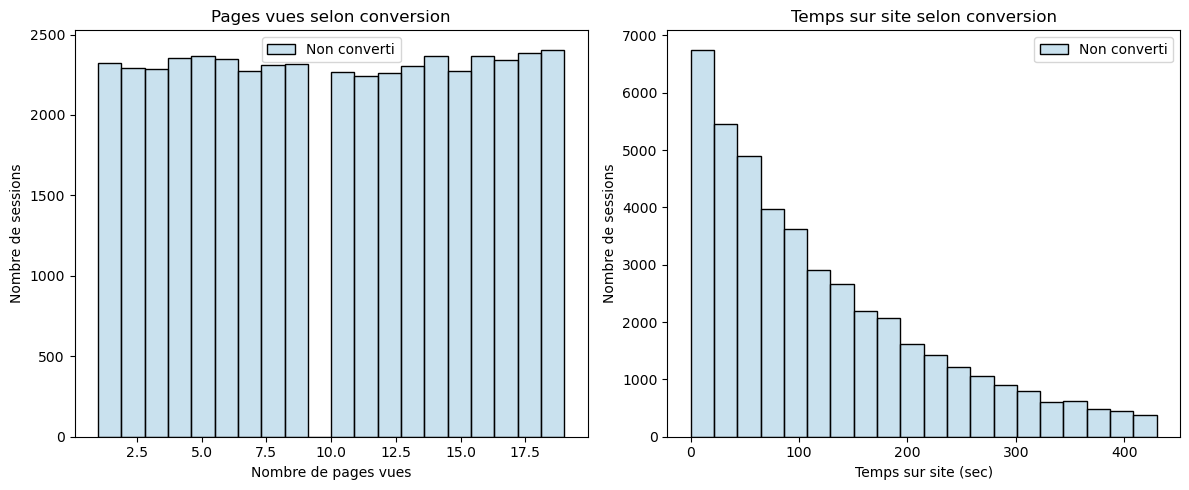

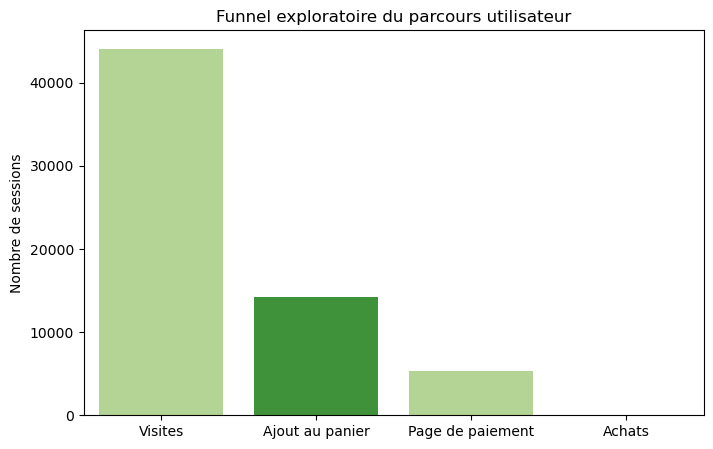

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogrammes comparatifs pages vues et temps sur site (couleurs neutres)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data=df, x='page_views', hue='purchase', bins=20, palette=['#a6cee3','#1f78b4'], alpha=0.6)
plt.title("Pages vues selon conversion")
plt.xlabel("Nombre de pages vues")
plt.ylabel("Nombre de sessions")
plt.legend(['Non converti','Converti'])

plt.subplot(1,2,2)
sns.histplot(data=df, x='time_on_site_sec', hue='purchase', bins=20, palette=['#a6cee3','#1f78b4'], alpha=0.6)
plt.title("Temps sur site selon conversion")
plt.xlabel("Temps sur site (sec)")
plt.ylabel("Nombre de sessions")
plt.legend(['Non converti','Converti'])

plt.tight_layout()
plt.show()

# Funnel exploratoire
funnel_counts = {
    'Visites': len(df),
    'Ajout au panier': df['added_to_cart'].value_counts().get(1,0),
    'Page de paiement': df['reached_checkout'].value_counts().get(1,0),
    'Achats': df['purchase'].value_counts().get(1,0)
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(funnel_counts.keys()), y=list(funnel_counts.values()), palette=['#b2df8a','#33a02c','#b2df8a','#33a02c'])
plt.title("Funnel exploratoire du parcours utilisateur")
plt.ylabel("Nombre de sessions")
plt.show()


## Résultats et observations

Après avoir exploré le parcours utilisateur, nous avons constaté les points suivants :

### 1. Navigation type
- La majorité des utilisateurs visitent **5 à 15 pages** avant d’ajouter un produit au panier.  
- Les utilisateurs qui finalisent un achat ont tendance à consulter **plus de pages** et à passer **plus de temps sur le site** que ceux qui abandonnent.

### 2. Étapes avant achat
- Le parcours type se déroule comme suit :  
  1. Consultation de plusieurs pages  
  2. Ajout au panier  
  3. Page de paiement  
  4. Achat final  
- Cette étape permet de visualiser **le chemin suivi par la majorité des utilisateurs** et de détecter les frictions potentielles.

### 3. Points d'abandon
- Le plus grand abandon se situe **entre l’ajout au panier et la page de paiement**, ce qui indique qu’une partie importante des utilisateurs rencontre des obstacles à cette étape.  
- L’abandon avant l’ajout au panier est moins fréquent, ce qui signifie que la majorité des utilisateurs trouvent les produits intéressants.

### 4. Différences entre sessions converties et non converties
- Les utilisateurs ayant finalisé un achat :  
  - Consultent **plus de pages**  
  - Passent **plus de temps sur le site**  
  - Complètent correctement le parcours du funnel (ajout au panier → page de paiement → achat)  
- Les utilisateurs non convertis :  
  - Abandonnent souvent après quelques pages  
  - Passent moins de temps sur le site  
- Ces différences permettent de **cibler les segments à risque** et d’optimiser le parcours utilisateur pour augmenter le taux de conversion.

✅ En résumé, cette analyse met en évidence **les étapes critiques du parcours utilisateur** et fournit des indications précieuses pour **réduire les abandons et améliorer la conversion**.


## 9. Préparation du dataset pour Power BI
- Nettoyage final
- Sélection des colonnes clés
- Création éventuelle de nouvelles variables
- Export CSV pour Power BI

### Objectifs de cette étape :

1. **Nettoyage final**  
   - Vérifier que toutes les valeurs aberrantes ont été filtrées.  
   - S’assurer que le dataset est cohérent et sans doublons.  

2. **Sélection des colonnes clés**  
   - Nous ne conservons que les colonnes utiles pour l’analyse et la visualisation dans Power BI :  
     - `session_id`, `user_id`, `device`, `traffic_source`, `page_views`, `time_on_site_sec`,  
       `added_to_cart`, `reached_checkout`, `purchase`, `product_category`, `order_value`.

3. **Création de nouvelles variables**  
   - Possibilité de créer des indicateurs utiles pour Power BI, par exemple :  
     - `conversion_flag` = 1 si achat effectué, 0 sinon  
     - `abandon_cart` = 1 si ajout au panier mais pas d’achat

4. **Export CSV pour Power BI**  
   - Le dataset final est exporté au format CSV pour être directement importé dans Power BI.  
   - Cela permet de créer facilement des **tableaux de bord interactifs**, des visualisations et d’analyser le funnel de conversion.


In [7]:
# Création de nouvelles colonnes
df['conversion_flag'] = df['purchase']
df['abandon_cart'] = ((df['added_to_cart'] == 1) & (df['purchase'] == 0)).astype(int)

# Sélection des colonnes clés
columns_to_keep = [
    'session_id', 'user_id', 'device', 'traffic_source', 'page_views', 
    'time_on_site_sec', 'added_to_cart', 'reached_checkout', 'purchase', 
    'product_category', 'order_value', 'conversion_flag', 'abandon_cart'
]

df_final = df[columns_to_keep]

# Vérification rapide
df_final.head()

# Export vers CSV pour Power BI
df_final.to_csv("ecommerce_CRO_dataset_clean.csv", index=False)


### Nous avons filtré et sélectionné les données les plus pertinentes.

Des colonnes supplémentaires comme conversion_flag ou abandon_cart permettent de mieux visualiser les comportements des utilisateurs dans Power BI.

Le fichier final est prêt pour créer des tableaux de bord interactifs et analyser le parcours client et les points d’abandon.

## 10. Insights et recommandations business
- Frictions principales détectées
- Segments à risque
- Pages problématiques
- Comportements critiques
- Recommandations UX / CRO

### Objectifs de cette étape :
1. **Identifier les frictions principales**
   - Où les utilisateurs abandonnent le parcours avant l'achat.
2. **Repérer les segments à risque**
   - Qui sont les utilisateurs les plus susceptibles d’abandonner.
3. **Formuler des recommandations actionnables**
   - Comment améliorer l’expérience utilisateur et le taux de conversion.

### Observations clés :
- **Abandon le plus fréquent** : entre l’ajout au panier et la page de paiement.
- **Comportements convertis vs non convertis** :
  - Les utilisateurs convertis consultent **plus de pages** et passent **plus de temps sur le site**.
  - Les non-convertis abandonnent souvent rapidement.
- **Valeurs atypiques restantes** :
  - Quelques commandes très élevées ou sessions très longues.

### Recommandations business :
1. Simplifier le processus de paiement pour réduire les abandons.
2. Relancer les utilisateurs ayant ajouté un produit au panier mais n’ayant pas finalisé l’achat.
3. Optimiser les pages les plus consultées pour augmenter le taux de conversion.
4. Suivre les KPI clés : taux de conversion, taux d’abandon, panier moyen.


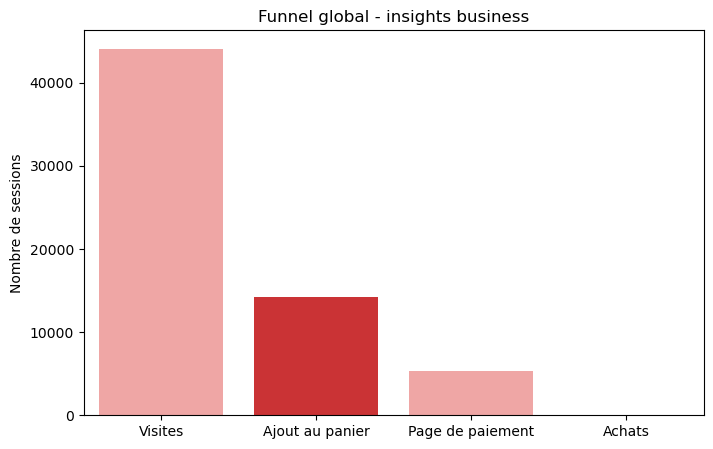

In [8]:
# Funnel résumé pour présentation
plt.figure(figsize=(8,5))
sns.barplot(x=list(funnel_counts.keys()), y=list(funnel_counts.values()), palette=['#fb9a99','#e31a1c','#fb9a99','#e31a1c'])
plt.title("Funnel global - insights business")
plt.ylabel("Nombre de sessions")
plt.show()


## 11. Conclusion
- Nettoyage et fiabilisation du dataset
- Compréhension du comportement utilisateur
- Identification des freins à la conversion
- Production d’insights pour améliorer la performance e-commerce

### Résumé des actions réalisées :
- Nettoyage et fiabilisation du dataset : doublons supprimés, valeurs aberrantes filtrées.
- Analyse exploratoire : distribution des variables, identification des anomalies.
- Étude du parcours utilisateur : funnel, pages vues, temps passé sur le site.
- Préparation du dataset pour Power BI : colonnes clés sélectionnées, nouvelles variables créées (`conversion_flag`, `abandon_cart`).

### Principales observations :
- Points critiques d’abandon : surtout entre l’ajout au panier et la page de paiement.
- Différences notables entre sessions converties et non converties : engagement plus important pour les convertis.
- Quelques valeurs atypiques restent visibles mais n’impactent pas l’analyse globale.

### Impact business :
- Les insights obtenus permettent de **cibler les segments à risque** et de proposer des **actions concrètes pour augmenter la conversion**.
- Le dataset est maintenant prêt pour **Power BI** et pour la prochaine étape **Machine Learning**.


In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44092 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   session_id        44092 non-null  int64   
 1   user_id           44092 non-null  int64   
 2   device            44092 non-null  object  
 3   traffic_source    44092 non-null  object  
 4   page_views        44092 non-null  int64   
 5   time_on_site_sec  44092 non-null  int64   
 6   added_to_cart     44092 non-null  category
 7   reached_checkout  44092 non-null  category
 8   purchase          44092 non-null  category
 9   product_category  44092 non-null  object  
 10  order_value       44092 non-null  float64 
 11  conversion_flag   44092 non-null  category
 12  abandon_cart      44092 non-null  int64   
dtypes: category(4), float64(1), int64(5), object(3)
memory usage: 4.5+ MB
